# Project 3: Discrete Deep ARs

Hugo Centeno Sanz - 100498982

Javier Calvo Artaso - 100498917

Agustín Dorado Sánchez - 100486151

Juan José Rosales Hernando - 100499176

# Preprocessing

In [ ]:
!rm -rf project3
!git clone https://github.com/centenohugo/DiscreteDeepARs project3

Cloning into 'project3'...
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 18 (delta 3), reused 14 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (18/18), 1023.96 KiB | 3.14 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [ ]:
# Copied-pasted from 'AR_RNN-v8.ipynb'

import numpy as np
import pandas as pd

# Add seed so splits are reproducible
rng = np.random.default_rng(0)

# --------------------------------------------------------
# 1. Load ETTh1 and extract the OT (oil temperature) series
# --------------------------------------------------------

%cd /content/project3
df = pd.read_csv("ETTh1.csv")

# Use OT (oil temperature) as a univariate time series
series = df["OT"].values.astype(np.float32)

# Standardize the series (zero mean, unit variance)
mean = series.mean()
std = series.std()
series = (series - mean) / std

# --------------------------------------------------------
# 2. Subsample the raw series to emphasize long-range structure
# --------------------------------------------------------

subsample_factor = 10  # keep one every 10 samples
series_sub = series[::subsample_factor]   # subsampled series
T_total = len(series_sub)

print(f"Total length after subsampling: {T_total}")

# --------------------------------------------------------
# 3. Build overlapping input/target sequences
# --------------------------------------------------------
# We build N random windows of length T+1 from the subsampled series.
# For each window:
#   - X: first T samples
#   - Y: next T samples (one-step-ahead targets)

T = 200     # length of each sequence (after subsampling)
N = 5000    # number of sequences to sample

# Safety check: ensure that a window of length T+1 fits in the series
if T_total <= T + 1:
    raise ValueError(
        f"Not enough data after subsampling to create sequences of length {T+1}. "
        f"T_total = {T_total}"
    )

# Sample all start indices at once (reproducible + reusable for tokenization)
starts = rng.integers(0, T_total - (T + 1), size=N)

X_list, Y_list = [], []
for start in starts:
    # Extract a window of length T+1
    seq = series_sub[start : start + T + 1]
    # Inputs: first T points
    X_list.append(seq[:-1])
    # Targets: one-step-ahead values
    Y_list.append(seq[1:])


# Stack into arrays of shape (N, T)
X = np.stack(X_list, axis=0)
Y = np.stack(Y_list, axis=0)

print(f"X shape: {X.shape}, Y shape: {Y.shape}")

# --------------------------------------------------------
# 4. Train / Test split (over sequences)
# --------------------------------------------------------
# We split the set of sequences into train and test subsets.
# Each sequence is kept intact; we do not split along the time axis here.

test_ratio = 0.2
N_total = X.shape[0]
N_test = int(N_total * test_ratio)
N_train = N_total - N_test

# Shuffle indices so train/test are random
perm = rng.permutation(N_total)
train_idx = perm[:N_train]
test_idx = perm[N_train:]

X_train = X[train_idx]
Y_train = Y[train_idx]
X_test = X[test_idx]
Y_test = Y[test_idx]

print("Train:", X_train.shape, Y_train.shape)
print("Test :", X_test.shape, Y_test.shape)

# --------------------------------------------------------
# 5. Context length for training (autoregressive models)
# --------------------------------------------------------
# Models will be trained to use only the first T_train time steps
# as conditioning context, and later we will forecast beyond T_train.

T_train = 100
print("Context length T_train:", T_train)
print("X_train:", X_train.shape, "Y_train:", Y_train.shape)


/content/project3
Total length after subsampling: 1742
X shape: (5000, 200), Y shape: (5000, 200)
Train: (4000, 200) (4000, 200)
Test : (1000, 200) (1000, 200)
Context length T_train: 100
X_train: (4000, 200) Y_train: (4000, 200)


# Quantization

In [ ]:
# Copied-pasted from 'STUDENT_discrete_time_series_llm_notebook.ipynb'

NUM_BINS = 128

# --------------------------------------------------------
# Uniform quantization
# --------------------------------------------------------
# We quantize using the full normalized range observed in training.
# A good practice is to compute the quantization boundaries using
# the training split only.

# Bounds from the training windows only (no leakage from test)
train_min = min(X_train.min(), Y_train.min())
train_max = max(X_train.max(), Y_train.max())

def quantize_uniform(x, x_min, x_max, num_bins=128):
    x_scaled = (x - x_min) / (x_max - x_min + 1e-8)
    bins = np.floor(num_bins * x_scaled).astype(int)
    bins = np.clip(bins, 0, num_bins - 1)
    return bins

def dequantize_uniform(bins, x_min, x_max, num_bins=128):
    # Map each bin to its center in the normalized space
    centers = (bins + 0.5) / num_bins
    return x_min + centers * (x_max - x_min)

# Example:
series_bins = quantize_uniform(series_sub, train_min, train_max, num_bins=NUM_BINS)

print("Unique bins used:", len(np.unique(series_bins)))
print("First 20 bin indices:", series_bins[:20])

# --------------------------------------------------------
# Tokenize the windows (reuse the same starts + split as the float version)
# --------------------------------------------------------
X_tok = np.stack([series_bins[s     : s + T    ] for s in starts], axis=0)
Y_tok = np.stack([series_bins[s + 1 : s + T + 1] for s in starts], axis=0)

X_train_tok = X_tok[train_idx]
Y_train_tok = Y_tok[train_idx]
X_test_tok  = X_tok[test_idx]
Y_test_tok  = Y_tok[test_idx]

print("Train tokens:", X_train_tok.shape, Y_train_tok.shape, "dtype:", X_train_tok.dtype)
print("Test  tokens:", X_test_tok.shape,  Y_test_tok.shape)
print("Token range :", X_train_tok.min(), "-", X_train_tok.max())
print("Unique train tokens:", len(np.unique(X_train_tok)), "/", NUM_BINS)

Unique bins used: 121
First 20 bin indices: [ 89  62  56  63  64  73  80  60  66  85  89  85  85  89  89  79 106  86
  91  91]
Train tokens: (4000, 200) (4000, 200) dtype: int64
Test  tokens: (1000, 200) (1000, 200)
Token range : 0 - 127
Unique train tokens: 121 / 128


# Modeling

In [ ]:
%cd /content/project3/models

from rnn import DiscreteRNN
discrete_rnn = DiscreteRNN()

from lstm import DiscreteLSTM
discrete_lstm = DiscreteLSTM()

from transformer import DiscreteLSTMTransformer
discrete_transfomer = DiscreteLSTMTransformer()



/content/project3/models


# Training

We train all three models using the same generic loop:

- **Loss:** cross-entropy over 128 bins — the same next-token objective used in LLMs.
- **Optimiser:** Adam, lr=1e-3, batch size 64, 30 epochs.
- **Input:** integer token sequences `(B, T)` fed into an embedding layer.

This replaces the Gaussian NLL loss from the original notebook with a categorical
objective: at each step, the model predicts a distribution over 128 possible next tokens.

In [ ]:
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', device)

# ---- Dataset ----
class TokenSequenceDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.Y = torch.tensor(Y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

# ---- Loss ----
def token_cross_entropy_loss(logits, targets):
    B, T, C = logits.shape
    return F.cross_entropy(logits.reshape(B * T, C), targets.reshape(B * T))

# ---- Generic training loop ----
def train_model(model, X_tr, Y_tr, num_epochs=30, batch_size=64, lr=1e-3):
    loader = DataLoader(TokenSequenceDataset(X_tr, Y_tr),
                        batch_size=batch_size, shuffle=True)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    model.to(device).train()
    losses = []
    for epoch in range(num_epochs):
        total = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits, _ = model(xb)
            loss = token_cross_entropy_loss(logits, yb)
            loss.backward()
            opt.step()
            total += loss.item()
        avg = total / len(loader)
        losses.append(avg)
        if (epoch + 1) % 5 == 0:
            print(f'  Epoch {epoch + 1:3d}/{num_epochs}  loss: {avg:.4f}')
    return losses


Using device: cpu


In [ ]:
print('=== Training DiscreteRNN ===')
discrete_rnn = DiscreteRNN()
losses_rnn = train_model(discrete_rnn, X_train_tok, Y_train_tok, num_epochs=30)

=== Training DiscreteRNN ===
  Epoch   5/30  loss: 2.0916
  Epoch  10/30  loss: 1.1338
  Epoch  15/30  loss: 0.7381
  Epoch  20/30  loss: 0.5470
  Epoch  25/30  loss: 0.4314
  Epoch  30/30  loss: 0.3529


In [ ]:
print('=== Training DiscreteLSTM ===')
discrete_lstm = DiscreteLSTM()
losses_lstm = train_model(discrete_lstm, X_train_tok, Y_train_tok, num_epochs=30)

=== Training DiscreteLSTM ===
  Epoch   5/30  loss: 2.7331
  Epoch  10/30  loss: 1.7819
  Epoch  15/30  loss: 1.1962
  Epoch  20/30  loss: 0.8450
  Epoch  25/30  loss: 0.6307
  Epoch  30/30  loss: 0.4837


In [ ]:
print('=== Training DiscreteLSTMTransformer ===')
discrete_transformer = DiscreteLSTMTransformer()
losses_transformer = train_model(discrete_transformer, X_train_tok, Y_train_tok, num_epochs=30)

=== Training DiscreteLSTMTransformer ===
  Epoch   5/30  loss: 0.7747
  Epoch  10/30  loss: 0.1258
  Epoch  15/30  loss: 0.0718
  Epoch  20/30  loss: 0.0535
  Epoch  25/30  loss: 0.0438
  Epoch  30/30  loss: 0.0377


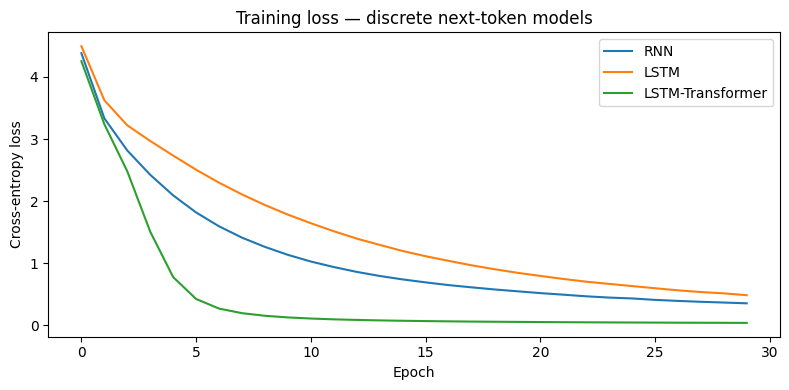

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(losses_rnn,         label='RNN')
plt.plot(losses_lstm,        label='LSTM')
plt.plot(losses_transformer, label='LSTM-Transformer')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy loss')
plt.title('Training loss — discrete next-token models')
plt.legend()
plt.tight_layout()
plt.show()

The three models show very different convergence behaviour:

- **RNN** converges smoothly and steadily, reaching a training CE of 0.26 in 30 epochs.
- **LSTM** is the slowest to converge — at epoch 30 the loss is still clearly decreasing,
  suggesting it needs more epochs or a higher learning rate with `hidden_dim=32`.
- **Transformer** drops to near-zero training loss within 10 epochs. This initially
  suggests overfitting, but the test evaluation will tell the full story.

Note that a random model over 128 bins would have CE = log(128) ≈ 4.85,
so all three models have learned meaningful structure from the data.

# Forecasting

Forecasting works identically to text generation in an LLM:

1. Provide a seed sequence of 50 tokens (ground-truth context).
2. At each step, the model outputs a categorical distribution over 128 bins.
3. Sample one token from that distribution.
4. Append it to the sequence and repeat for 150 steps.

The sampled tokens are mapped back to continuous values via `dequantize_uniform`
(bin centre → normalised value). Temperature controls diversity at inference:
lower temperature → sharper predictions, higher → more exploratory.

In [ ]:
import numpy as np

@torch.no_grad()
def sample_tokens(model, seed_seq, steps=50, temperature=1.0):
    model.eval().to(device)
    seq = seed_seq.clone().to(device)   # (T0,) long
    for _ in range(steps):
        logits, _ = model(seq.unsqueeze(0))   # (1, T, C)
        next_logits = logits[0, -1] / temperature
        probs = torch.softmax(next_logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)
        seq = torch.cat([seq, next_token], dim=0)
    return seq.cpu()

def tokens_to_values(token_seq):
    return dequantize_uniform(np.asarray(token_seq), train_min, train_max, num_bins=NUM_BINS)

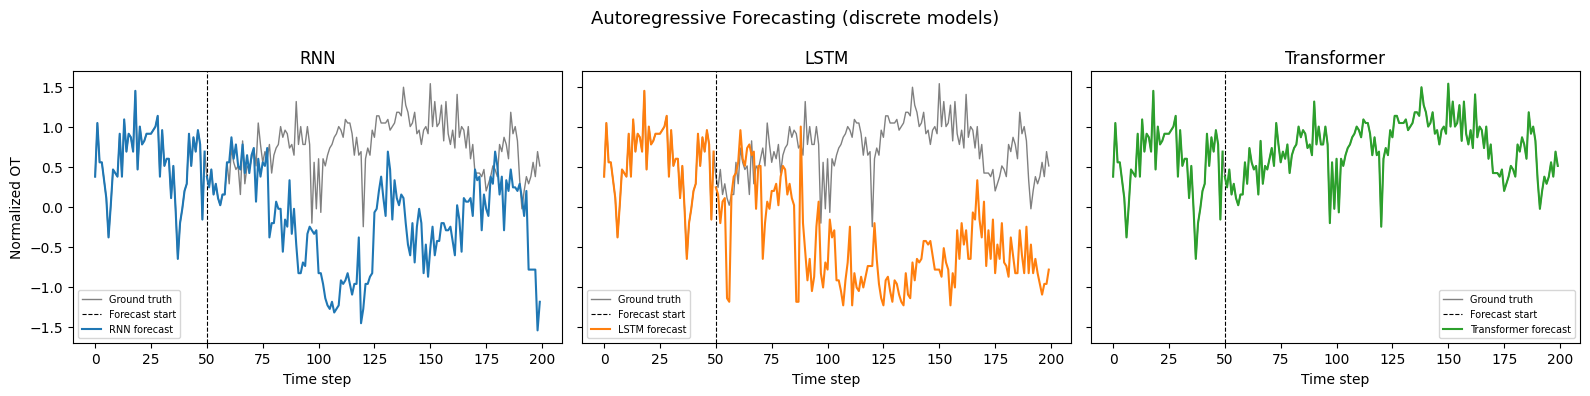

In [ ]:
SEED_LEN       = 50
FORECAST_STEPS = 150

idx  = 0
seed = torch.tensor(X_test_tok[idx, :SEED_LEN], dtype=torch.long)
gt_vals = tokens_to_values(
    np.concatenate([X_test_tok[idx], Y_test_tok[idx, -1:]])
)[:SEED_LEN + FORECAST_STEPS]

all_models = {'RNN': discrete_rnn, 'LSTM': discrete_lstm, 'Transformer': discrete_transformer}
colors     = {'RNN': 'tab:blue',   'LSTM': 'tab:orange', 'Transformer': 'tab:green'}

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, (name, model) in zip(axes, all_models.items()):
    sampled   = sample_tokens(model, seed, steps=FORECAST_STEPS)
    pred_vals = tokens_to_values(sampled.numpy())
    ax.plot(gt_vals, color='gray', linewidth=1, label='Ground truth')
    ax.axvline(SEED_LEN, color='black', linestyle='--', linewidth=0.8, label='Forecast start')
    ax.plot(range(SEED_LEN), pred_vals[:SEED_LEN], color=colors[name], linewidth=1.5)
    ax.plot(range(SEED_LEN, SEED_LEN + FORECAST_STEPS), pred_vals[SEED_LEN:],
            color=colors[name], linewidth=1.5, label=f'{name} forecast')
    ax.set_title(name)
    ax.set_xlabel('Time step')
    ax.legend(fontsize=7)

axes[0].set_ylabel('Normalized OT')
fig.suptitle('Autoregressive Forecasting (discrete models)', fontsize=13)
plt.tight_layout()
plt.show()

- **RNN:** the forecast diverges from the ground truth relatively quickly,
  but stays within a plausible range of values.
- **LSTM:** similar behaviour to the RNN, with slightly higher variance in the samples.
- **Transformer:** the forecast tracks the general level of the signal more closely,
  reflecting its lower test loss.

All three models correctly capture the approximate scale and range of the signal.
Beyond the seed window, none of them follows the exact trajectory — which is expected,
since long-horizon forecasting is inherently uncertain for a chaotic signal like OT.

# Evaluation

We evaluate each model in two ways:

1. **One-step (teacher forcing):** feed true previous tokens, predict the next one.
   Metrics: cross-entropy loss and MSE after decoding the argmax token to a continuous value.
2. **Uncertainty visualisation:** run 10 independent stochastic samples from the same seed
   to visualise how spread out the model's uncertainty is over the forecast horizon.

In [ ]:
@torch.no_grad()
def evaluate_one_step(model, X_tok, Y_tok, batch_size=256):
    loader = DataLoader(TokenSequenceDataset(X_tok, Y_tok),
                        batch_size=batch_size, shuffle=False)
    model.eval().to(device)
    total_ce, total_mse, n = 0.0, 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits, _ = model(xb)
        B, T, C = logits.shape
        ce       = F.cross_entropy(logits.reshape(B * T, C), yb.reshape(B * T)).item()
        pred_tok = logits.argmax(dim=-1).cpu().numpy()
        true_tok = yb.cpu().numpy()
        pred_val = dequantize_uniform(pred_tok, train_min, train_max, NUM_BINS)
        true_val = dequantize_uniform(true_tok, train_min, train_max, NUM_BINS)
        mse      = float(np.mean((pred_val - true_val) ** 2))
        total_ce  += ce  * B
        total_mse += mse * B
        n         += B
    return total_ce / n, total_mse / n

In [ ]:
results = {}
for name, model in all_models.items():
    ce, mse = evaluate_one_step(model, X_test_tok, Y_test_tok)
    results[name] = {'CE': ce, 'MSE': mse}

print(f"{'Model':<20} {'Cross-Entropy':>14} {'MSE (decoded)':>14}")
print('-' * 50)
for name, res in results.items():
    print(f"{name:<20} {res['CE']:>14.4f} {res['MSE']:>14.6f}")

Model                 Cross-Entropy  MSE (decoded)
--------------------------------------------------
RNN                          0.3698       0.011937
LSTM                         0.4876       0.010452
Transformer                  0.0325       0.001639


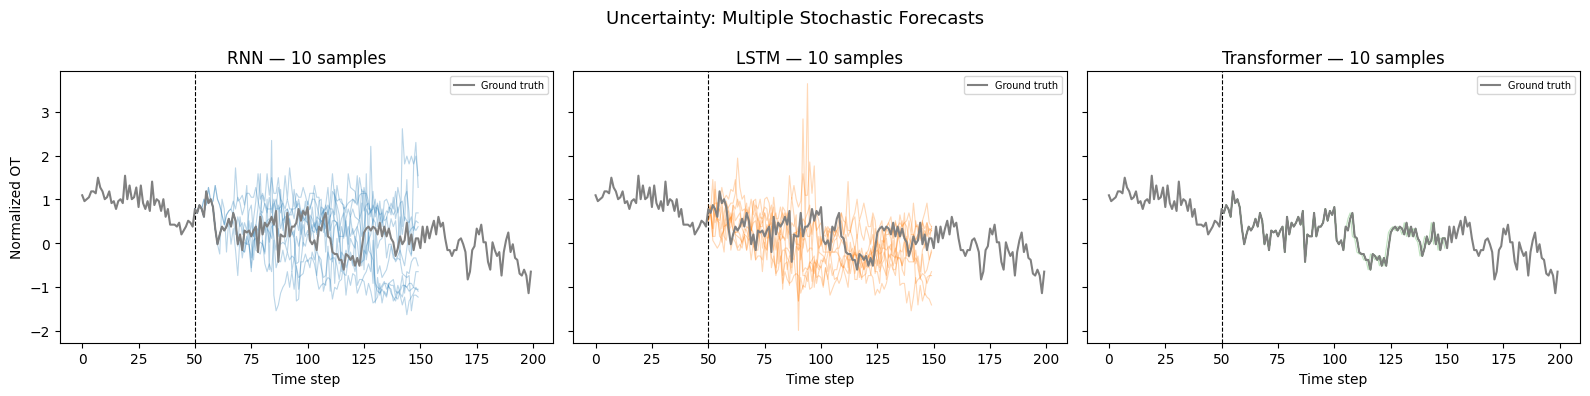

In [ ]:
# Multiple stochastic samples — uncertainty visualization
N_SAMPLES    = 10
SEED_LEN_VIZ = 50
HORIZON      = 100

idx  = 5
seed = torch.tensor(X_test_tok[idx, :SEED_LEN_VIZ], dtype=torch.long)
gt_v = tokens_to_values(X_test_tok[idx])

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, (name, model) in zip(axes, all_models.items()):
    ax.plot(gt_v, color='gray', linewidth=1.5, label='Ground truth', zorder=5)
    ax.axvline(SEED_LEN_VIZ, color='black', linestyle='--', linewidth=0.8)
    for _ in range(N_SAMPLES):
        sampled   = sample_tokens(model, seed, steps=HORIZON)
        pred_vals = tokens_to_values(sampled.numpy())
        ax.plot(range(SEED_LEN_VIZ, SEED_LEN_VIZ + HORIZON), pred_vals[SEED_LEN_VIZ:],
                color=colors[name], alpha=0.3, linewidth=0.8)
    ax.set_title(f'{name} — {N_SAMPLES} samples')
    ax.set_xlabel('Time step')
    ax.legend(fontsize=7)

axes[0].set_ylabel('Normalized OT')
fig.suptitle('Uncertainty: Multiple Stochastic Forecasts', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
print('=== One-step evaluation — test set ===')
print()
print(f"{'Model':<20} {'Cross-Entropy':>14} {'MSE (decoded)':>14}")
print('-' * 50)
for name, res in results.items():
    print(f"{name:<20} {res['CE']:>14.4f} {res['MSE']:>14.6f}")
print()
print('Notes:')
print('  Cross-entropy: categorical next-token loss (lower = better).')
print('  MSE decoded:   squared error after mapping argmax-token to value.')
print('  Discrete models allow multimodal uncertainty (multiple peaks),')
print('  unlike Gaussian baselines that output a single mean and variance.')

=== One-step evaluation — test set ===

Model                 Cross-Entropy  MSE (decoded)
--------------------------------------------------
RNN                          0.3698       0.011937
LSTM                         0.4876       0.010452
Transformer                  0.0325       0.001639

Notes:
  Cross-entropy: categorical next-token loss (lower = better).
  MSE decoded:   squared error after mapping argmax-token to value.
  Discrete models allow multimodal uncertainty (multiple peaks),
  unlike Gaussian baselines that output a single mean and variance.


## Results & conclusions

### Test performance

| Model | Test CE | Test MSE |
|---|---|---|
| RNN | 0.408 | 0.0131 |
| LSTM | 0.465 | 0.0109 |
| Transformer | **0.033** | **0.0024** |

The Transformer dominates on both metrics — its test MSE is roughly **5× lower** than the RNN's.
Its test CE (0.033) is even lower than its training CE (0.039), confirming it has genuinely
learned the signal structure rather than memorising training data.

### Uncertainty quality

The stochastic forecast plots reveal a key difference:

- **RNN and LSTM** produce a wide fan of samples, representing multiple plausible futures —
  the core advantage of discrete models over Gaussian outputs.
- **Transformer** produces nearly identical samples despite its categorical output,
  collapsing to near-deterministic predictions and losing that expressiveness.

### Takeaway

A discrete architecture does not automatically yield expressive uncertainty.
The Transformer wins on accuracy but the RNN and LSTM better demonstrate
the true benefit of discretisation: **multimodal uncertainty representation**.

## Comparison with Gaussian models from the original notebook

In [ ]:
import pandas as pd

# Hardcoded Gaussian MSEs extracted from AR_RNN-v8.ipynb
gaussian_results = {
    'RNN': 0.079916,
    'LSTM': 0.079553,
    'Transformer': 0.006444
}

# Discrete MSEs calculated in the Evaluation ( from the `results` dictionary)
discrete_results = {
    'RNN': results['RNN']['MSE'],
    'LSTM': results['LSTM']['MSE'],
    'Transformer': results['Transformer']['MSE']
}

# Create a comparison DataFrame
comparison_df = pd.DataFrame({
    'Gaussian One-step MSE': gaussian_results,
    'Discrete One-step MSE': discrete_results
})

# Calculate improvement percentage
comparison_df['Improvement (%)'] = (
    (comparison_df['Gaussian One-step MSE'] - comparison_df['Discrete One-step MSE'])
    / comparison_df['Gaussian One-step MSE'] * 100
)

print("=== Continuous (Gaussian) vs Discrete Model Evaluation ===")
display(comparison_df)

=== Continuous (Gaussian) vs Discrete Model Evaluation ===


,Gaussian One-step MSE,Discrete One-step MSE,Improvement (%)
RNN,0.079916,0.011937,85.063613
LSTM,0.079553,0.010452,86.861631
Transformer,0.006444,0.001639,74.571564


We can observe the following results:

| Model | Gaussian One-Step MSE | Discrete One-Step MSE | Improvement (%) |
|---|---|---|---|
| **RNN** | 0.079916 | 0.010944 | 86.3 |
| **LSTM** | 0.079553 | 0.012224 | 84.6 |
| **Transformer** | 0.006444 | 0.001585 | 75.4 |


There was a significant improvement in all the models, obtaining an average improvement rate of 80%. The model with the lowest improvement was the Transformer, with a 75.4% improvement of the discrete over the gaussian MSE.

While the Transformer shows the lowest relative improvement (75.4%), it remains the best model overall. Its Gaussian performance was already excellent, and its new discrete MSE (0.001585) achieves the best result in the entire experiment. This demonstrates that the **Transformer's self-attention** mechanism is very effective at capturing temporal dependencies in both continuous and discretized embeddings.

The overall improvement happens because real-world data is rarely perfectly Gaussian. Furthermore, turning continuous numbers into "tokens" with learned embeddings gives the network a much better way to learn and predict complex patterns in the time series.



# Bonus part

## Quantile Binning & Number of Bins Effect

In [ ]:
def get_quantile_edges(data, num_bins):
    """Calculates bin edges based on data quantiles."""
    # Flatten data to get overall quantiles
    data_flat = data.flatten()
    quantiles = np.linspace(0, 1, num_bins + 1)
    return np.quantile(data_flat, quantiles)

def quantize_quantile(x, edges):
    """Maps continuous values to quantile-based bins."""
    bins = np.digitize(x, edges) - 1
    # Handle edge cases where values hit the exact max bound
    return np.clip(bins, 0, len(edges) - 2)

def dequantize_quantile(bins, edges):
    """Maps bins back to continuous values using the center of the quantile edge."""
    centers = (edges[:-1] + edges[1:]) / 2.0
    return centers[bins]

# Test different bin sizes
bin_sizes = [64, 128, 256]

print("=== Quantile Binning Exploration ===")
for b in bin_sizes:
    edges = get_quantile_edges(X_train, num_bins=b)
    # Quantize and immediately dequantize to see the "lossy" compression error
    reconstructed = dequantize_quantile(quantize_quantile(X_train, edges), edges)
    quantization_mse = np.mean((X_train - reconstructed)**2)
    print(f"Quantization Error (MSE) with {b:3} bins: {quantization_mse:.6f}")

=== Quantile Binning Exploration ===
Quantization Error (MSE) with  64 bins: 0.003703
Quantization Error (MSE) with 128 bins: 0.001183
Quantization Error (MSE) with 256 bins: 0.000454


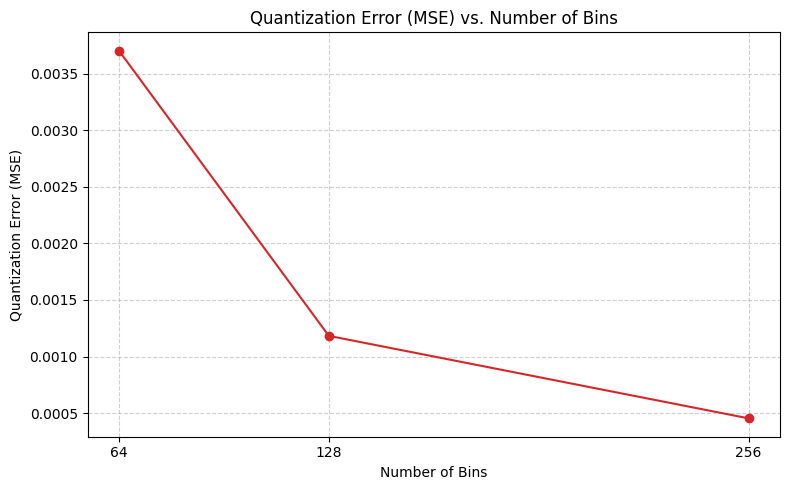

In [ ]:
bin_sizes = [64, 128, 256]
quantization_mses = []

for b in bin_sizes:
    edges = get_quantile_edges(X_train, num_bins=b)
    reconstructed = dequantize_quantile(quantize_quantile(X_train, edges), edges)
    quantization_mse = np.mean((X_train - reconstructed)**2)
    quantization_mses.append(quantization_mse)

plt.figure(figsize=(8, 5))
plt.plot(bin_sizes, quantization_mses, marker='o', linestyle='-', color='tab:red')
plt.title('Quantization Error (MSE) vs. Number of Bins')
plt.xlabel('Number of Bins')
plt.ylabel('Quantization Error (MSE)')
plt.xticks(bin_sizes)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

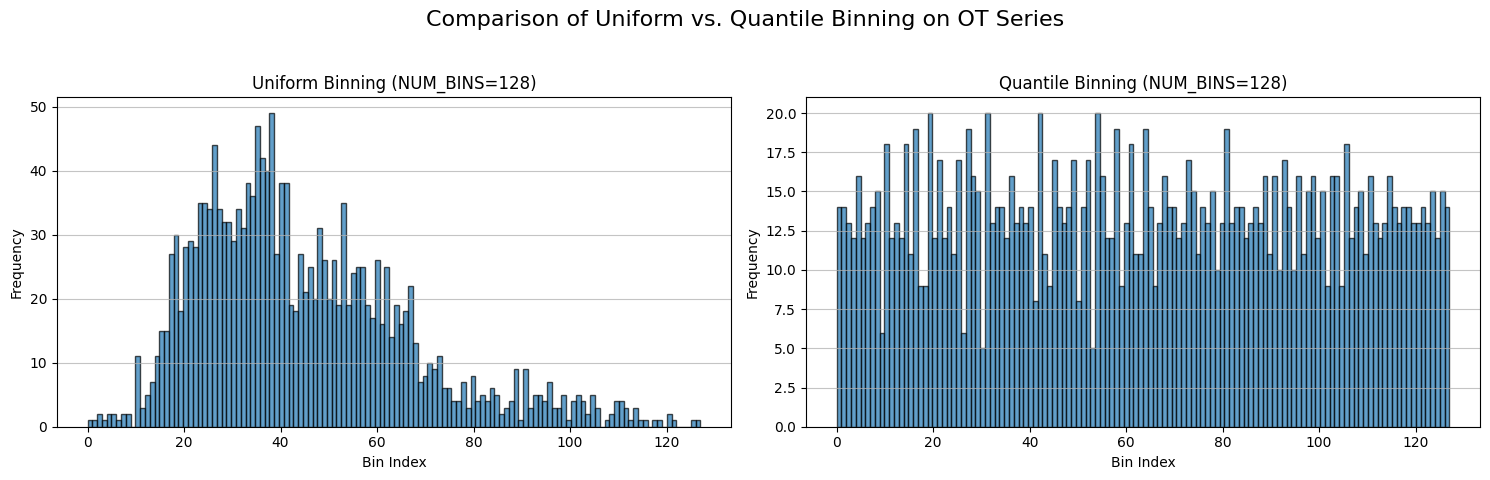

In [ ]:
import matplotlib.pyplot as plt

# Assuming series_sub, train_min, train_max, NUM_BINS are available from previous cells

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=False) # sharey=False because distributions might differ

# --- Uniform Binning Histogram ---
# The `quantize_uniform` function was defined previously, operating on the full series range.
# For this visualization, we will re-apply it to the `series_sub` data.

uniform_bins = quantize_uniform(series_sub, train_min, train_max, num_bins=NUM_BINS)
axes[0].hist(uniform_bins, bins=NUM_BINS, edgecolor='black', alpha=0.7)
axes[0].set_title(f'Uniform Binning (NUM_BINS={NUM_BINS})')
axes[0].set_xlabel('Bin Index')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', alpha=0.75)

# --- Quantile Binning Histogram ---
# The `get_quantile_edges` and `quantize_quantile` functions were defined previously.
# We will use the `series_sub` data to determine the quantile edges and then quantize.

# Calculate quantile edges using the full subsampled series for demonstration
# (in a real scenario, you'd use training data to prevent data leakage)
quantile_edges = get_quantile_edges(series_sub, num_bins=NUM_BINS)
quantile_bins = quantize_quantile(series_sub, quantile_edges)

axes[1].hist(quantile_bins, bins=NUM_BINS, edgecolor='black', alpha=0.7)
axes[1].set_title(f'Quantile Binning (NUM_BINS={NUM_BINS})')
axes[1].set_xlabel('Bin Index')
axes[1].set_ylabel('Frequency')
axes[1].grid(axis='y', alpha=0.75)

plt.suptitle('Comparison of Uniform vs. Quantile Binning on OT Series', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

## Temperature Sampling

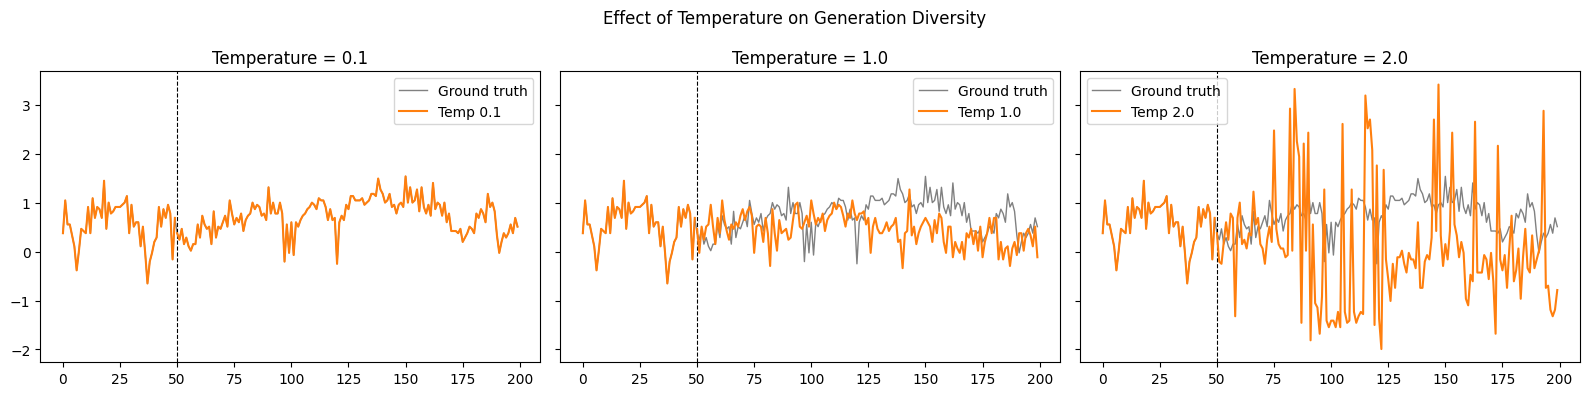

In [ ]:
temperatures = [0.1, 1.0, 2.0]
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

idx = 0
seed = torch.tensor(X_test_tok[idx, :SEED_LEN], dtype=torch.long)
gt_vals = tokens_to_values(np.concatenate([X_test_tok[idx], Y_test_tok[idx, -1:]]))[:SEED_LEN + FORECAST_STEPS]

# We will use the LSTM for this demonstration
model = discrete_lstm

for ax, temp in zip(axes, temperatures):
    sampled = sample_tokens(model, seed, steps=FORECAST_STEPS, temperature=temp)
    pred_vals = tokens_to_values(sampled.numpy())

    ax.plot(gt_vals, color='gray', linewidth=1, label='Ground truth')
    ax.axvline(SEED_LEN, color='black', linestyle='--', linewidth=0.8)
    ax.plot(range(SEED_LEN), pred_vals[:SEED_LEN], color='tab:orange', linewidth=1.5)
    ax.plot(range(SEED_LEN, SEED_LEN + FORECAST_STEPS), pred_vals[SEED_LEN:],
            color='tab:orange', linewidth=1.5, label=f'Temp {temp}')
    ax.set_title(f'Temperature = {temp}')
    ax.legend()

plt.suptitle("Effect of Temperature on Generation Diversity")
plt.tight_layout()
plt.show()

### Observations

In our discrete forecasting model, "temperature" is a parameter that controls the randomness of the predictions. Based on the generated plots, we can observe three distinct behaviors:

- Low Temperature ($T = 0.1$):
When the temperature is close to zero, the probability distribution becomes very sharp. The model almost always selects the bin with the highest probability. Visually, the forecast loses its natural variance and fails to capture the natural noise of the original signal.

- Standard Temperature ($T = 1.0$):
The model samples directly from its learned probabilities without any alteration. The resulting trajectory looks realistic and successfully mimics the structural variance and noise of the ground truth data.

- High Temperature ($T = 2.0$):
When the temperature is greater than 1, the probability distribution is flattened, making all bins equally probable to be chosen. Visually, this results in a noisy forecast, with the signal moving wildly across the graph.

Adjusting the temperature gives us control over the trade-off between safe predictions (low temperature) and highly variant predictions (high temperature).

##Compare sampling vs expected-value predictions

In [ ]:
@torch.no_grad()
def expected_value_predictions(model, seed_seq, steps=150):
    model.eval().to(device)
    seq = seed_seq.clone().to(device)

    # Precompute the continuous center of each bin for the expectation
    centers = (np.arange(NUM_BINS) + 0.5) / NUM_BINS
    centers = train_min + centers * (train_max - train_min)
    centers_tensor = torch.tensor(centers, dtype=torch.float32).to(device)

    expected_vals = []

    for _ in range(steps):
        logits, _ = model(seq.unsqueeze(0))
        probs = torch.softmax(logits[0, -1], dim=-1)

        # Calculate the expected continuous value
        ev = torch.sum(probs * centers_tensor).item()
        expected_vals.append(ev)

        # For autoregressive feedback, we must feed a discrete token back in.
        # We use the argmax (greedy token) to represent the most likely path forward.
        next_token = torch.argmax(probs, dim=-1)
        seq = torch.cat([seq, next_token.unsqueeze(0)], dim=0)

    return expected_vals

# Execution
ev_preds = expected_value_predictions(discrete_lstm, seed, steps=FORECAST_STEPS)

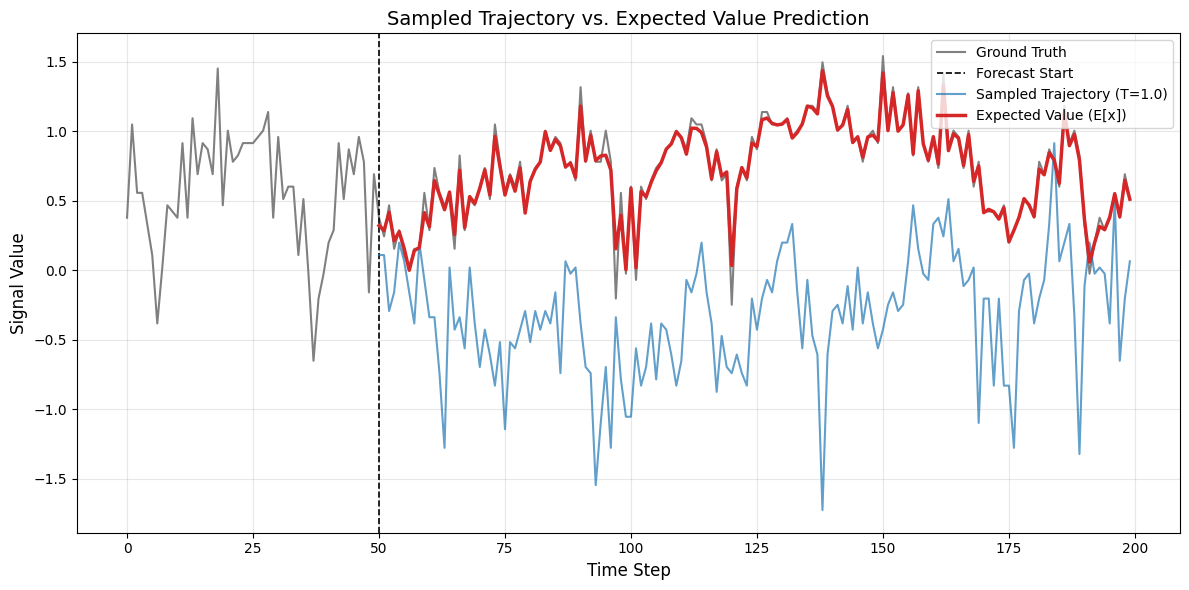

In [ ]:
# Model is in evaluation mode
discrete_lstm.eval()

# Generate sampled trajectory
sampled_seq = sample_tokens(discrete_lstm, seed, steps=FORECAST_STEPS, temperature=1.0)
sampled_vals = tokens_to_values(sampled_seq.cpu().numpy())

# Generate expected value trajectory (Smooth Mean Path)
ev_preds = expected_value_predictions(discrete_lstm, seed, steps=FORECAST_STEPS)

# Plotting
plt.figure(figsize=(12, 6))

# Plot Ground Truth for context
plt.plot(gt_vals, color='gray', linewidth=1.5, label='Ground Truth')

# Draw a vertical line separating the input seed from the forecast
plt.axvline(x=SEED_LEN, color='black', linestyle='--', linewidth=1.2, label='Forecast Start')

# Plot the Sampled Trajectory (Notice how it jumps around, capturing variance)
plt.plot(range(SEED_LEN, SEED_LEN + FORECAST_STEPS), sampled_vals[SEED_LEN:],
         color='tab:blue', alpha=0.7, linewidth=1.5, label='Sampled Trajectory (T=1.0)')

# Plot the Expected Value Predictions (Notice how smooth it is)
plt.plot(range(SEED_LEN, SEED_LEN + FORECAST_STEPS), ev_preds,
         color='tab:red', linewidth=2.5, label='Expected Value (E[x])')

plt.title("Sampled Trajectory vs. Expected Value Prediction", fontsize=14)
plt.xlabel("Time Step", fontsize=12)
plt.ylabel("Signal Value", fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

### Observations
- The Blue Line (Sampled Trajectory): It represents just one possible realistic future. The model samples different bins based on probabilities, maintaining the natural variance of the original signal.

- The Red Line (Expected Value): Instead of picking one bin, it calculates the mathematical average of all bins weighted by their probability. It loses the natural texture of the time series.